This lab is adapted from the IBM Quantum Learning module “The Deutsch-Jozsa algorithm” on the IBM Quantum platform
(see https://quantum.cloud.ibm.com/learning/en/modules/computer-science/deutsch-jozsa).

Import libraries

In [4]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler
import numpy as np
from IPython.display import Image
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.visualization import plot_histogram

## Introduction

This lab shows how quantum algorithms can learn global properties of functions more efficiently than classical methods. Starting from simple oracles, Deutsch’s and then Deutsch-Jozsa algorithms are used to decide whether a function is constant or balanced with a single quantum query. The same structure is then used to solve the Bernstein–Vazirani problem, recovering a hidden bit string in one shot.

# The Deutsch-Jozsa algorithm

## Quantum parallelism and its limits

Let $f$ be a function $f:\{0,1\}\rightarrow\{0,1\}$. There are four functions that $f$ could be, two are constant, with $f(0)=f(1)$, and two are balanced, with $f(0)\neq f(1)$. 

The four possible functions are shown below.

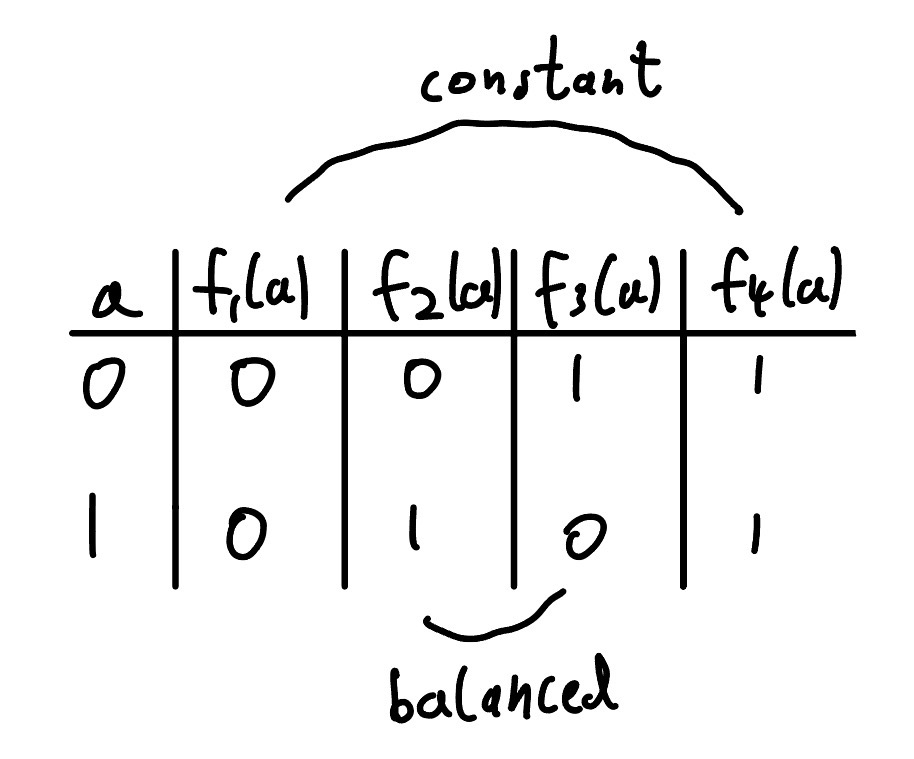

In [6]:
Image('4f.jpg',width=300)

Part of the power of quantum computing comes from quantum parallelism. A qubit in superposition allows a circuit to act on many classical inputs at once, but a single measurement cannot reveal all those values, only some global property.

The goal is to identify which of the four candidate functions $f(x)$ is used. Classically this requires evaluating $f(0)$ and $f(1)$. Trying to use superposition to reduce the amount of queries needed, consider Oracle $U_f$ with $U_f\left(|y\rangle|x\rangle\right)=|y\oplus f(x)\rangle|x\rangle\Rightarrow\text{for the state }|y\rangle=|0\rangle,U_f\left(|0\rangle|x\rangle\right)=|f(x)\rangle|x\rangle\Rightarrow$ qubit 0 encodes $x$ and qubit 1 encodes $f(x)$. Initialising qubit 0 in the superposition state $|+\rangle$, applying the oracle encodes the answers to both $f(0)$ and $f(1)$, since $U_f\left(|0\rangle|+\rangle\right)=\frac{1}{\sqrt{2}}\left(|f(0)\rangle|0\rangle+|f(1)\rangle|1\rangle\right)$.

As will be seen below, the issue here is that, after measurement, the superposition collapses to a single branch. A single pair $(x, f(x))$ with $x \in \{0,1\}$ is observed, and the value of $f$ at the other input is lost. Since each $x$ occurs with equal probability, repeated runs can give the same $x$ again, so at best, this approach requires as many queries as the classical method, and at worst requires even more.

This theory is tested on a quantum computer below. The circuit applies a Hadamard gate to the 0th qubit $\left(H|0\rangle=|+\rangle\right)$, then the oracle (twobit_function) is applied, and finally both qubit 0 and qubit 1 are measured.

In [25]:
# Load saved credentials
service = QiskitRuntimeService()
 
# Use the least busy backend, or uncomment the loading of a specific backend like "ibm_brisbane".
backend = service.least_busy(operational=True, simulator=False, min_num_qubits = 127)

print(backend.name)
 
 
sampler = Sampler(mode=backend)

management.get:WARNING:2025-11-11 11:35:37,173: Loading default saved account


ibm_torino


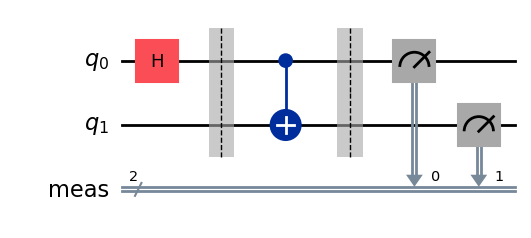

In [30]:
# Step 1: Map
qc = QuantumCircuit(2)
 
# this function is exactly deutsch_function, the four possible types of f are accounted for,
# the outcomes are explained in detail when it is defined in the Deutsch's algorithm section

def twobit_function(case: int):
    """
    Generate a valid two-bit function as a `QuantumCircuit`.
    """
    if case not in [1, 2, 3, 4]:
        raise ValueError("`case` must be 1, 2, 3, or 4.")
 
    f = QuantumCircuit(2)
    if case in [2, 3]:
        f.cx(0, 1)
    if case in [3, 4]:
        f.x(1)
    return f
# first, convert oracle circuit (above) to a single gate for drawing purposes. otherwise, the circuit is too large to display
# blackbox = twobit_function(2).to_gate()  # you may edit the number inside "twobit_function()" to select among the four valid functions
# blackbox.label = "$U_f$"
 
qc.h(0)
qc.barrier()
qc.compose(twobit_function(2), inplace=True)
qc.measure_all()
 
 
qc.draw("mpl")

In [27]:
# Step 2: Transpile
 
target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
 
qc_isa = pm.run(qc)

In [28]:
# Step 3: Run the job on a real quantum computer
 
job = sampler.run([qc_isa], shots=1)
# job = sampler_sim.run([qc_isa],shots=1) # uncomment this line to run on simulator instead
res = job.result()
counts = res[0].data.meas.get_counts()

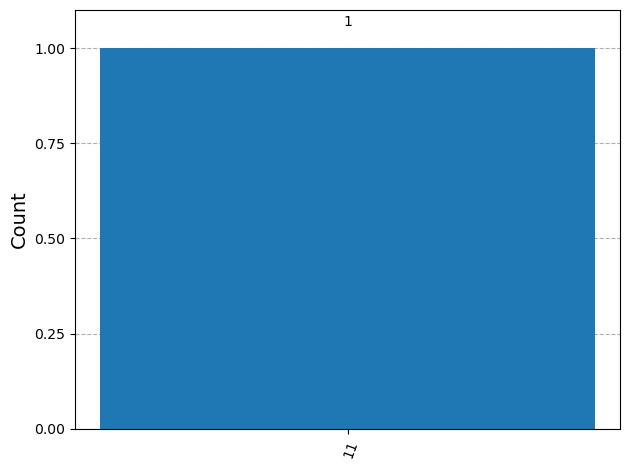

In [29]:
# Step 4: Visualize and analyze results
 
## Analysis

 
plot_histogram(counts)

The histogram shows that $x=1$ and $f(x)=f(1)=1$, so as expected, no general comment on $f$ can be made, the function could still be the balanced $f_2$, or the constant $f_4$. To figure out which function is being used, the number of shots are increased.

In [31]:
# Step 3: Run the job on a real quantum computer
 
job = sampler.run([qc_isa], shots=4)
# job = sampler_sim.run([qc_isa],shots=1) # uncomment this line to run on simulator instead
res = job.result()
counts = res[0].data.meas.get_counts()

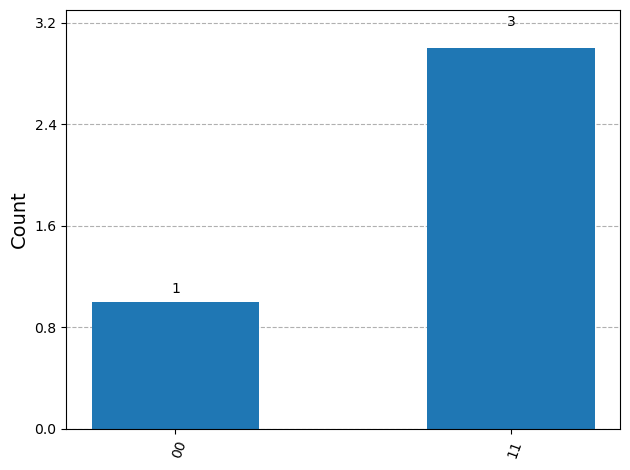

In [32]:
# Step 4: Visualize and analyze results
 
## Analysis

 
plot_histogram(counts)

The histogram shows that for $x=1,f(x)=1$, and that for $x=0,f(x)=0$, which means that the function is $f_2$ (balanced). 

The uneven distribution of outcomes shows that this approach does not reduce the query cost when compared to the classical method. In the best case it matches the classical strategy, and in the worst case repeated measurements give the same pair (e.g. $x=1,f(x)=1$), increasing the number of required queries.

## Deutsch's algorithm

Deutsch-Jozsa's algorithm is the first quantum algorithm to show an exponential query advantage over classical computation in this model. Deutsch’s algorithm is the $n=1$ special case. 

Deutsch’s problem asks whether $f$ is constant or balanced, which is equivalent to computing the parity $f(0)\oplus f(1)$. 

$f(0)\oplus f(1)$ is addition modulo 2, so if $f(0)=f(1)$ then $f(0)\oplus f(1)=0$ (constant), and if $f(0)\neq f(1)$ then $f(0)\oplus f(1)=1$ (balanced).


Deutsch’s algorithm is implemented by the circuit shown below.

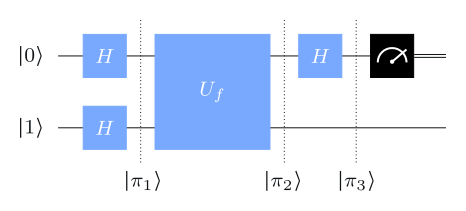

In [7]:
Image('Deutsch-circuit-states.png')

Consider the states $|\pi_1\rangle,|\pi_2\rangle,$ and $|\pi_3\rangle$ annotated above.

Using little-endian (least significant bit last) ordering convention, the initial state is $|1\rangle|0\rangle$.

Applying a Hadamard gate to both qubits gives the following.

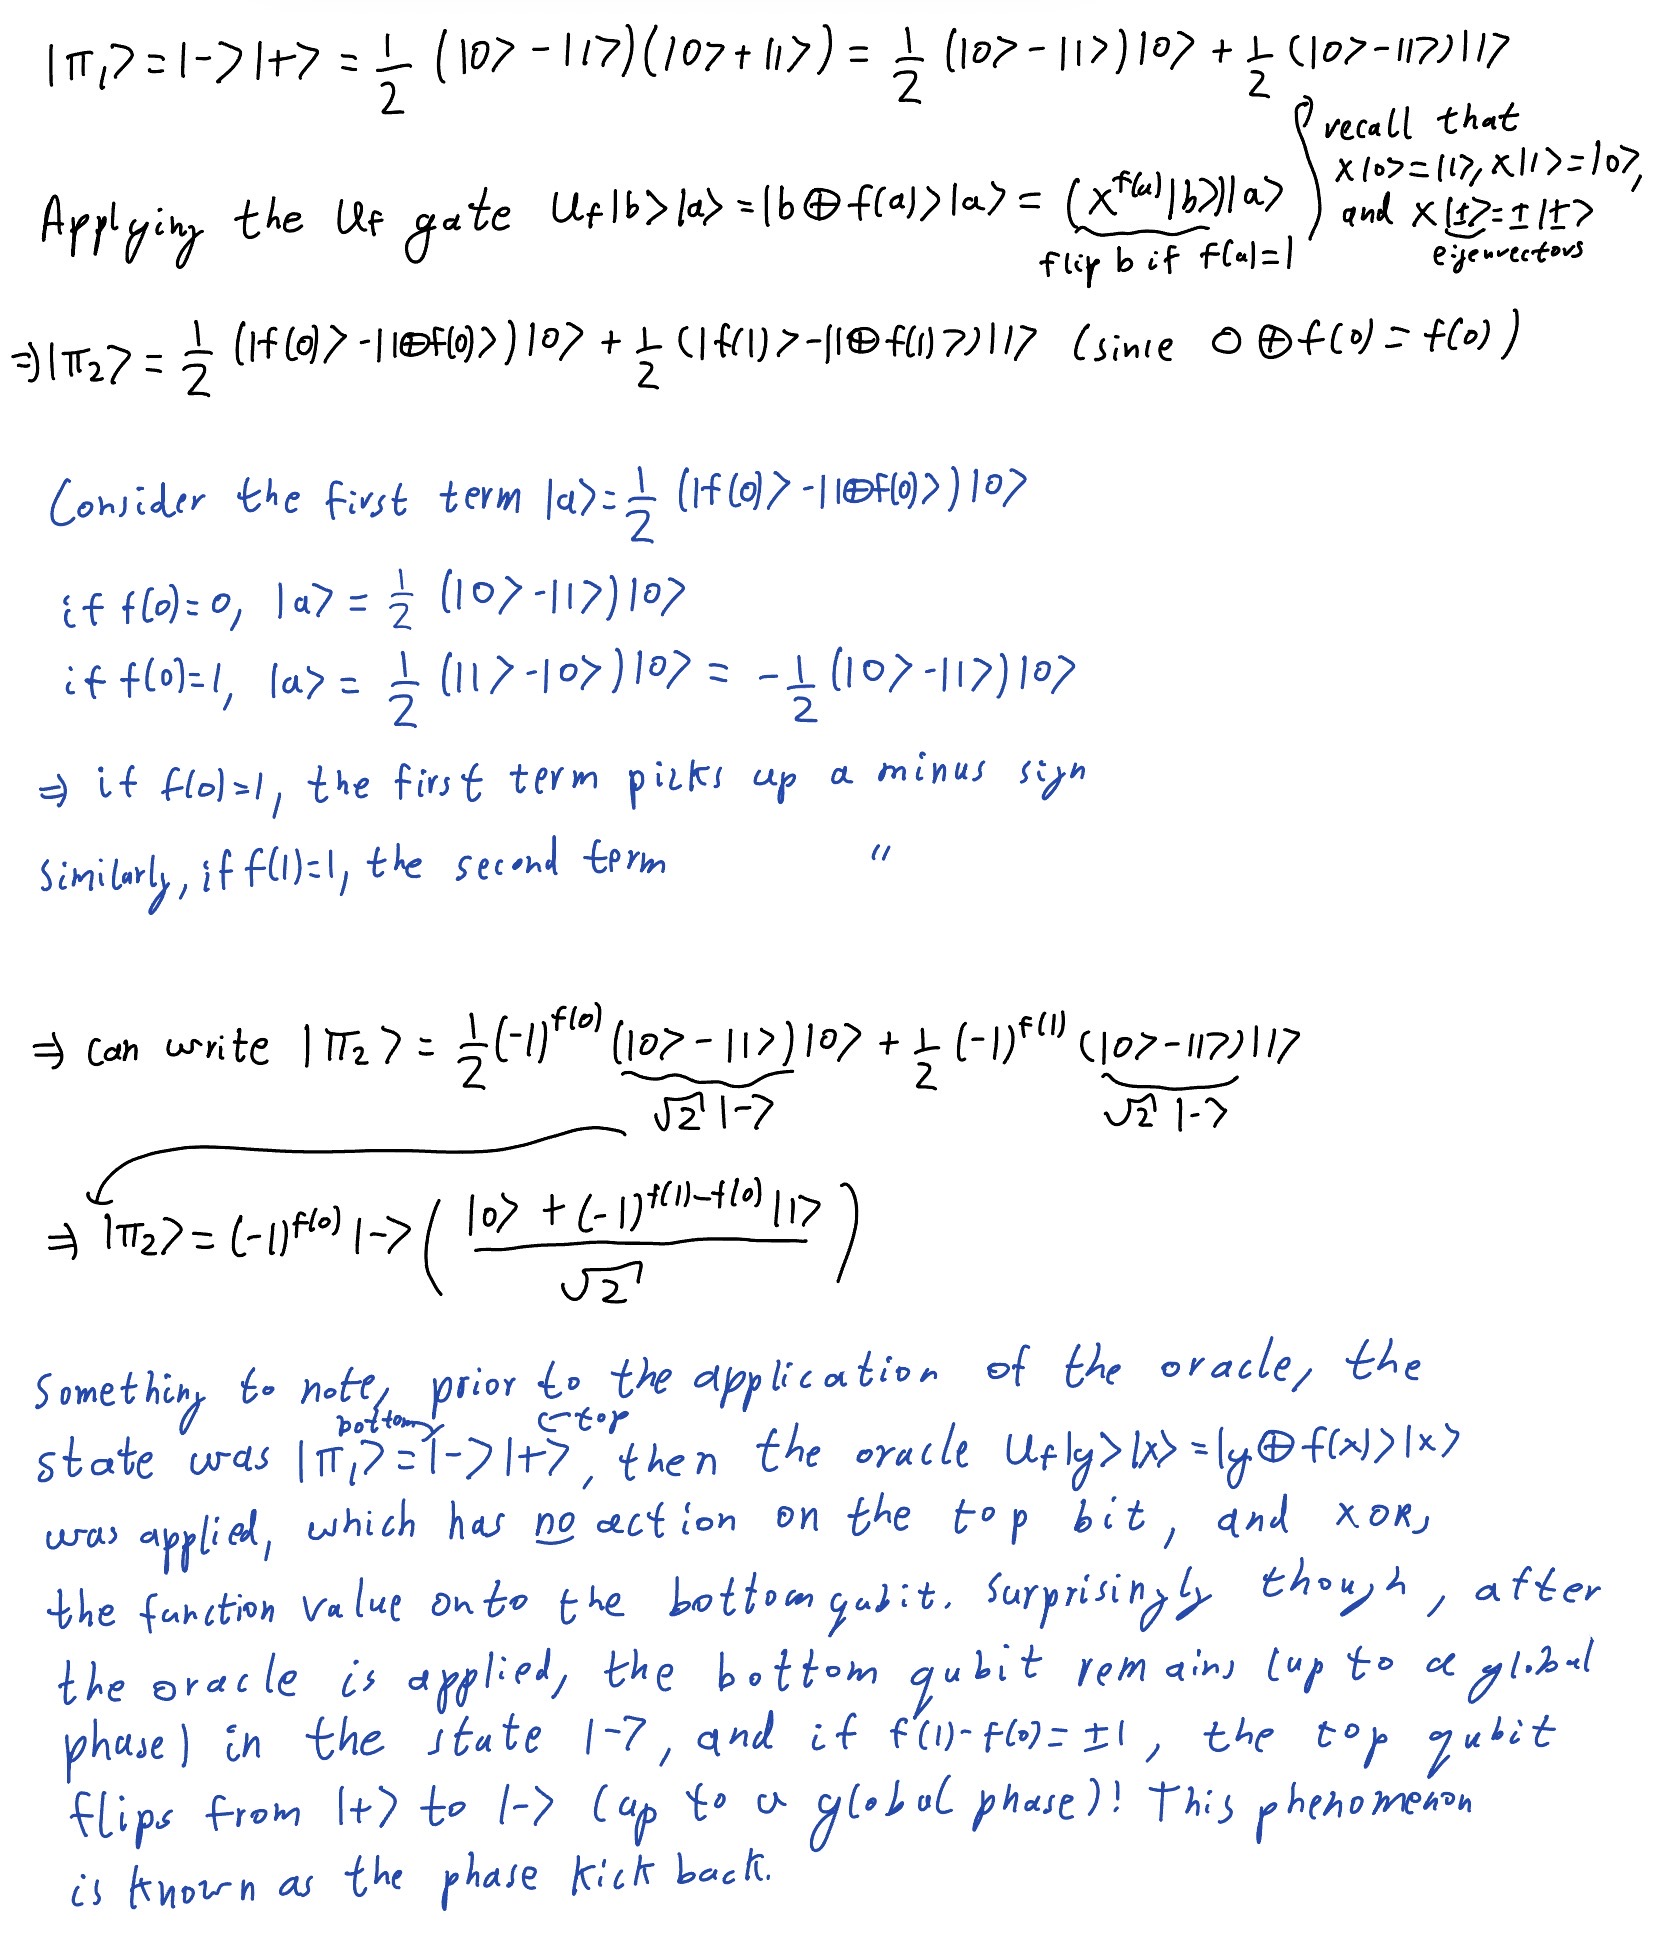

In [8]:
Image('DJ1.jpg')

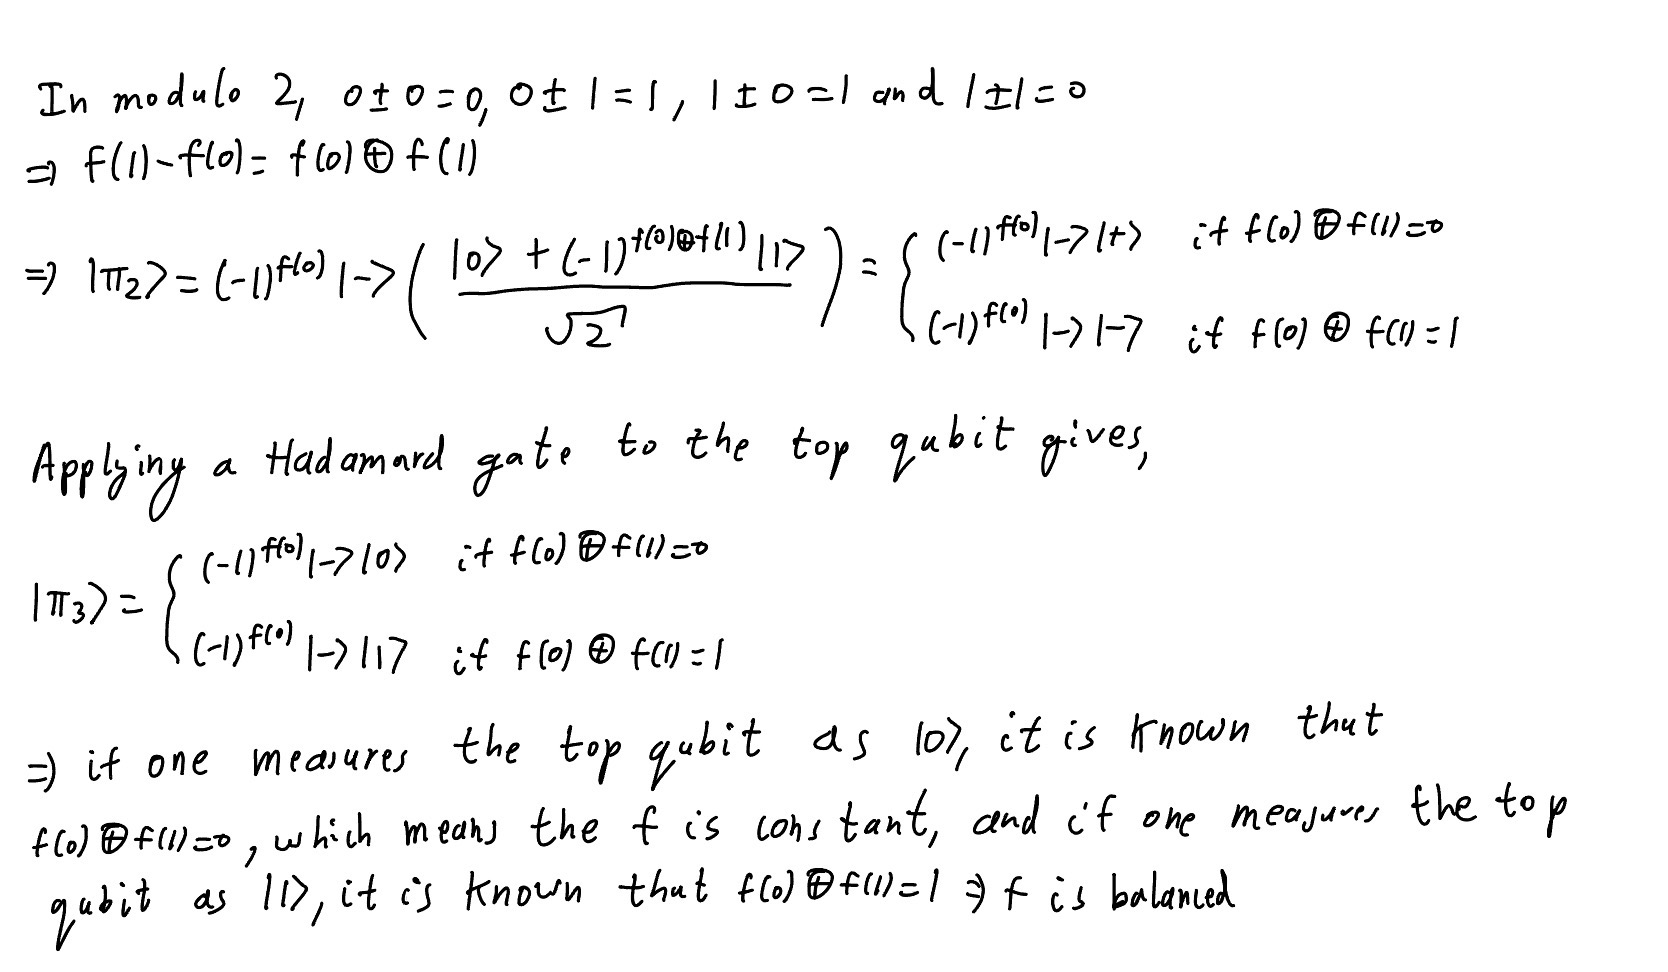

In [9]:
Image('DJ2.jpg')

## Implementation in Qiskit

Deutsch's algorithm is now verified using simulated quantum backend.

The function below is the oracle. 



In [5]:
def deutsch_function(case: int):
    # This function generates a quantum circuit for one of the 4 functions
    # from one bit to one bit
 
    if case not in [1, 2, 3, 4]:
        raise ValueError("`case` must be 1, 2, 3, or 4.")
 
    f = QuantumCircuit(2) #2 qubits
    if case in [2, 3]:
        f.cx(0, 1)
    if case in [3, 4]:
        f.x(1)
    return f

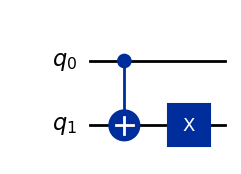

In [6]:
display(deutsch_function(3).draw(output="mpl"))

For the first case, the oracle applies the identity to both bits, meaning the only gates applied to the 0th qubit are the $H^2=I$ from the Deutsch's circuit, since this is initially in the state $|0\rangle$, the result is '0' $\Rightarrow f_1$ is constant. This is correct since $U_f\left(|b\rangle|a\rangle\right)=|b\rangle|a\rangle=|b\oplus f(a)\rangle|a\rangle\Rightarrow b=b\oplus f(a)\Rightarrow f(a)=0.$

The second case is shown below.

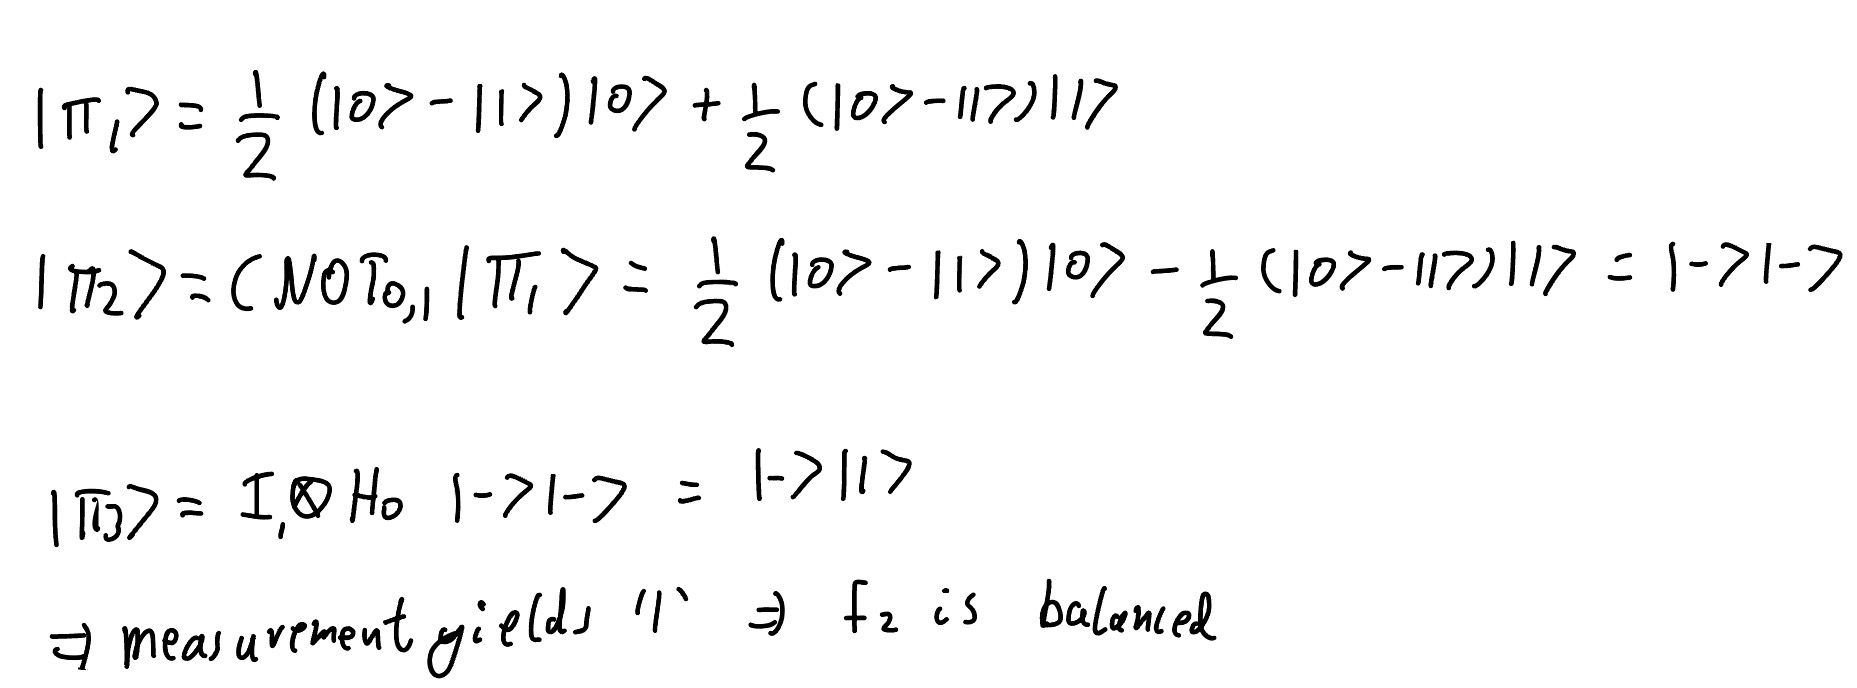

In [10]:
Image('f2.jpg')

This is correct since $U_f\left(|b\rangle|a\rangle\right)=CNOT(a,b)|b\rangle|a\rangle=|b\oplus a\rangle|a\rangle=|b\oplus f(a)\rangle|a\rangle\Rightarrow b\oplus a=b\oplus f(a)\Rightarrow f(a)=a.$

The third case is shown below.

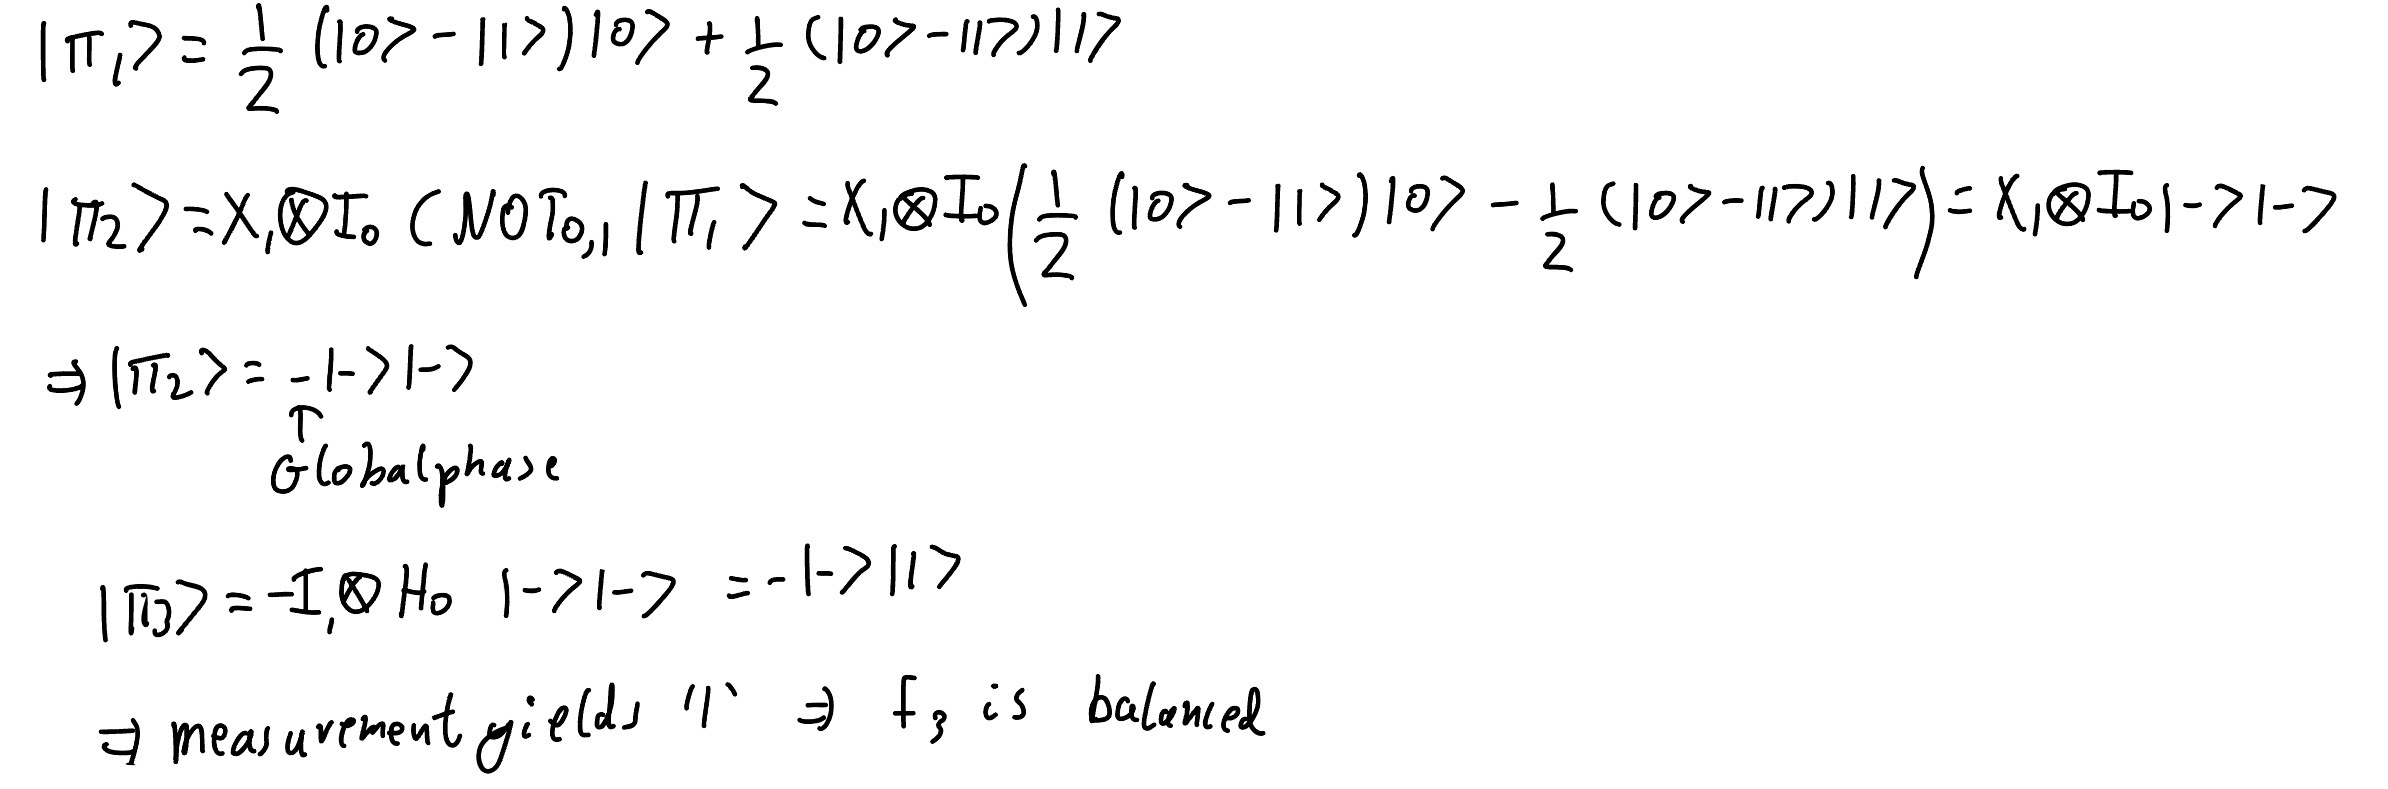

In [11]:
Image('f3.jpg')

This is correct since $U_f\left(|b\rangle|a\rangle\right)=X_b\otimes I_aCNOT(a,b)|b\rangle|a\rangle=X_b\otimes I_a|b\oplus a\rangle|a\rangle=|b\oplus a\oplus1\rangle|a\rangle=|b\oplus f(a)\rangle|a\rangle$

$\Rightarrow b\oplus a\oplus1=b\oplus f(a)\Rightarrow f(a)=a\oplus1.$

The fourth case is shown below.

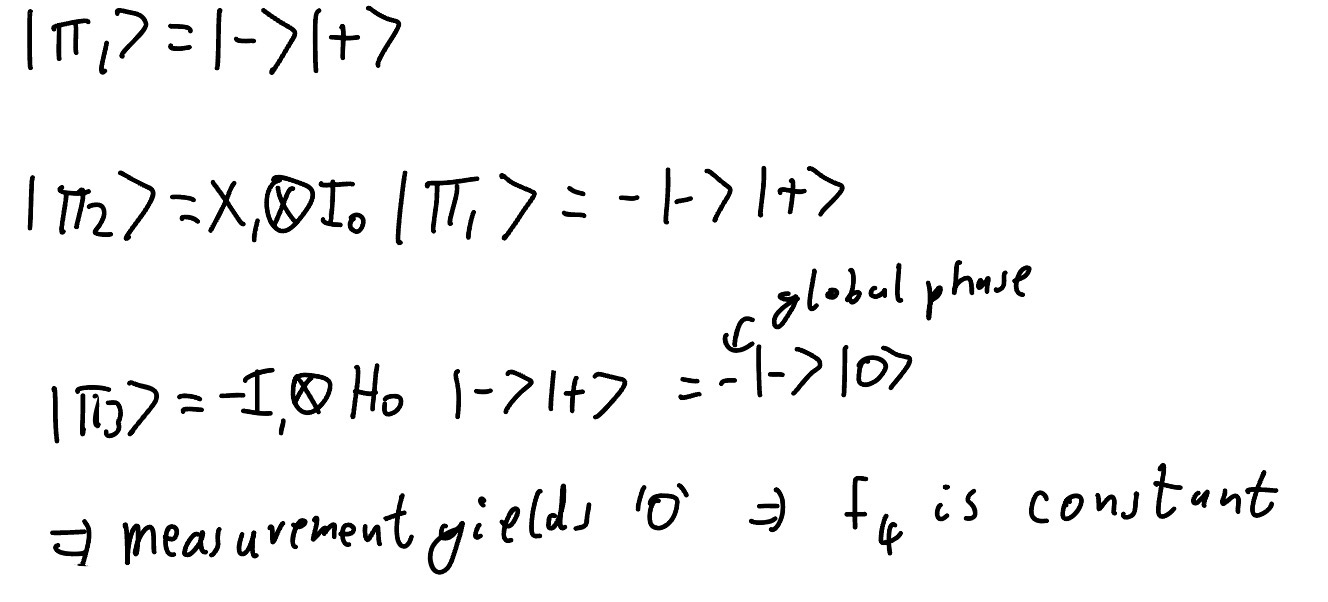

In [12]:
Image('f4.jpg',width=600)

This is correct since $U_f\left(|b\rangle|a\rangle\right)=X_b\otimes I_a|b\rangle|a\rangle=|b\oplus1\rangle|a\rangle=|b\oplus f(a)\rangle|a\rangle\Rightarrow b\oplus1=b\oplus f(a)\Rightarrow f(a)=1.$

The circuit to implement deutsch's algorithm is defined below. This can take in one of the four Deutsch's functions as input.

In [15]:
def compile_circuit(function: QuantumCircuit):
    # Compiles a circuit for use in Deutsch's algorithm.
# function is Deutsch function
    n = function.num_qubits - 1 
# deutsch_function has 2 qubits, so n=1, 1 input qubit, and have 1 ancilla (helper) qubit
    qc = QuantumCircuit(n + 1, n) # n input qubits,+ 1 ancilla qubit, n classical bits
 
    qc.x(n) # flip ancilla qubit to |1>
    qc.h(range(n + 1)) # apply hadamard to all qubits (including ancilla)
 
    qc.barrier()
    qc.compose(function, inplace=True) # apply oracle
    qc.barrier()
 
    qc.h(range(n)) # apply hadamard to all qubits except ancilla
    qc.measure(range(n), range(n)) #measure all qubits except ancilla, map  result to n classical bits
 
    return qc

For $5$ input qubits, the hadamards put all $2^5=32$ possible inputs $\left(|00000\rangle,00001\rangle,\text{ etc...}\right)$ into a superposition. The oracle acts on the whole superposition, and the measurement finds out if $f$ is constant or balanced. If output is $|00000\rangle$, $f$ is constant, if the output is any of the remaining 31 states, $f$ is balanced.

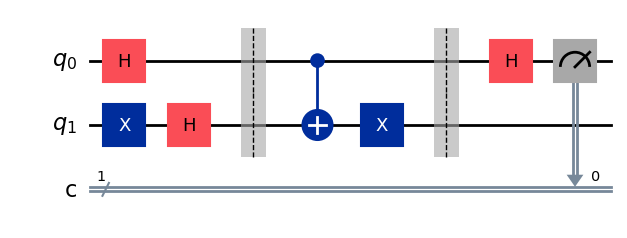

In [16]:
display(compile_circuit(deutsch_function(3)).draw(output="mpl"))

The code below runs the circuit for a single input qubit, and returns 'constant' if the measurement gives '0' and 'balanced' if the measurement gives '1'.

In [17]:
def deutsch_algorithm(function: QuantumCircuit):
    # Determine if a one-bit function is constant or balanced.
 
    qc = compile_circuit(function)
 
    result = AerSimulator().run(qc, shots=1, memory=True).result()
    measurements = result.get_memory() 
    if measurements[0] == "0":
        return "constant"
    return "balanced"

As before, expect $f_1,f_4$ to be constant, and $f_2,f_3$ to be balanced.

In [23]:
f1 = deutsch_function(1)
display(deutsch_algorithm(f1))

'constant'

In [22]:
f2 = deutsch_function(2)
display(deutsch_algorithm(f2))

'balanced'

In [21]:
f3 = deutsch_function(3)
display(deutsch_algorithm(f3))

'balanced'

In [24]:
f4 = deutsch_function(4)
display(deutsch_algorithm(f4))

'constant'

## The Deutsch-Jozsa algorithm

As alluded to earlier, with the compile_circuit function, the problem can be extended to n input bits and 1 ancilla bit, and is called the Deutsch-Jozsa algorithm. Similarly, if the algorithm returns a bitstring of n 0's, the function is constant (function always returns '1' or always returns '0'), and if the bitstring contains at least one '1', the function is balanced (the function returns '0' and '1' an equal number of times.

The code below randomly creates a balanced or constant function, for n qubits, and 1 ancilla qubit.

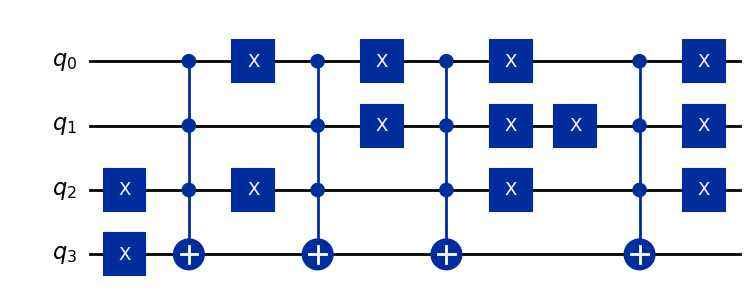

In [6]:
def dj_function(num_qubits):
    """
    Create a random Deutsch-Jozsa function.
    """
# num_qubits is amount of input qubits
    qc_dj = QuantumCircuit(num_qubits + 1)
    if np.random.randint(0, 2): #random integer between 0 (inclusive) and 2 (exclusive)
        # Flip output qubits with 50% chance (ancilla)
        qc_dj.x(num_qubits) #if true, f(x)=1 for all (at this stage)
    if np.random.randint(0, 2):
        # return constant circuit with 50% chance. Of this 50%, 50% have f(x)=0, 50% have f(x)=1
        return qc_dj
 
    # If the "if" statement above was "TRUE" then we've returned the constant
    # function and the function is complete. If not, we proceed in creating our
    # balanced function. Everything below is to produce the balanced function:
 
    # select half of all possible states at random:
    on_states = np.random.choice(
        range(2**num_qubits),  # numbers to sample from
        2**num_qubits // 2,  # number of samples
        replace=False,  # makes sure states are only sampled once
    )
# 0 means |000...0>, 1 means |000...01>, and so on, replace=False means that for e.g. 0 can't be 
# chosen twice
 
    def add_cx(qc_dj, bit_string):
        for qubit, bit in enumerate(reversed(bit_string)):
            if bit == "1":
                qc_dj.x(qubit)
        return qc_dj
# if bitstring is 1011, then qubit 0 is 1, so flip qubit 0, qubit 1 is 1, so flip qubit 1, qubit 2 is 0, 
# so do nothing, and qubit 3 is 1, so flip qubit 3
 
    for state in on_states:
        # qc_dj.barrier()  # Barriers are added to help visualize how the functions are created. 
        # They can safely be removed.
        qc_dj = add_cx(qc_dj, f"{state:0b}")
# regardless of num_qubits, so if there are 100 qubits, and 2nd state corresponds to state |00000...10>,
# f"{state:0b}" will give 10
# qc_dj is separate, but will have 100 qubits, so could be 010001010...11 
#qc_dj = add_cx(10001010...11,10) = 10001010...01
        qc_dj.mcx(list(range(num_qubits)), num_qubits)
#Flips ancilla if ALL input qubits are 1
        qc_dj = add_cx(qc_dj, f"{state:0b}")
# returns input qubits 
    # qc_dj.barrier()
 
    return qc_dj
# half of the states ancillas are flipped
 
n = 3  # number of input qubits
 
oracle = dj_function(n)
 
display(oracle.draw("mpl"))

For input $|0101\rangle,$ if $f(101)=0,\text{ }|0101\rangle\text{ goes to }|0101\rangle$, if $f(101)=1,\text{ }|0101\rangle\text{ goes to }|1101\rangle$. Constant would produce '0' or '1' for all inputs $|0000\rangle, |0001\rangle$, etc.. and '0' and '1' an equal amount of times if it's balanced. $U_f\left(|y\rangle|x\rangle\right)=|y\oplus f(x)\rangle|x\rangle\therefore$ if the ancilla flips, $f(x)=1$, and if it doesn't flip, $f(x)=0$.

dj_function is written out explicitly below for a specific case with 3 input qubits.

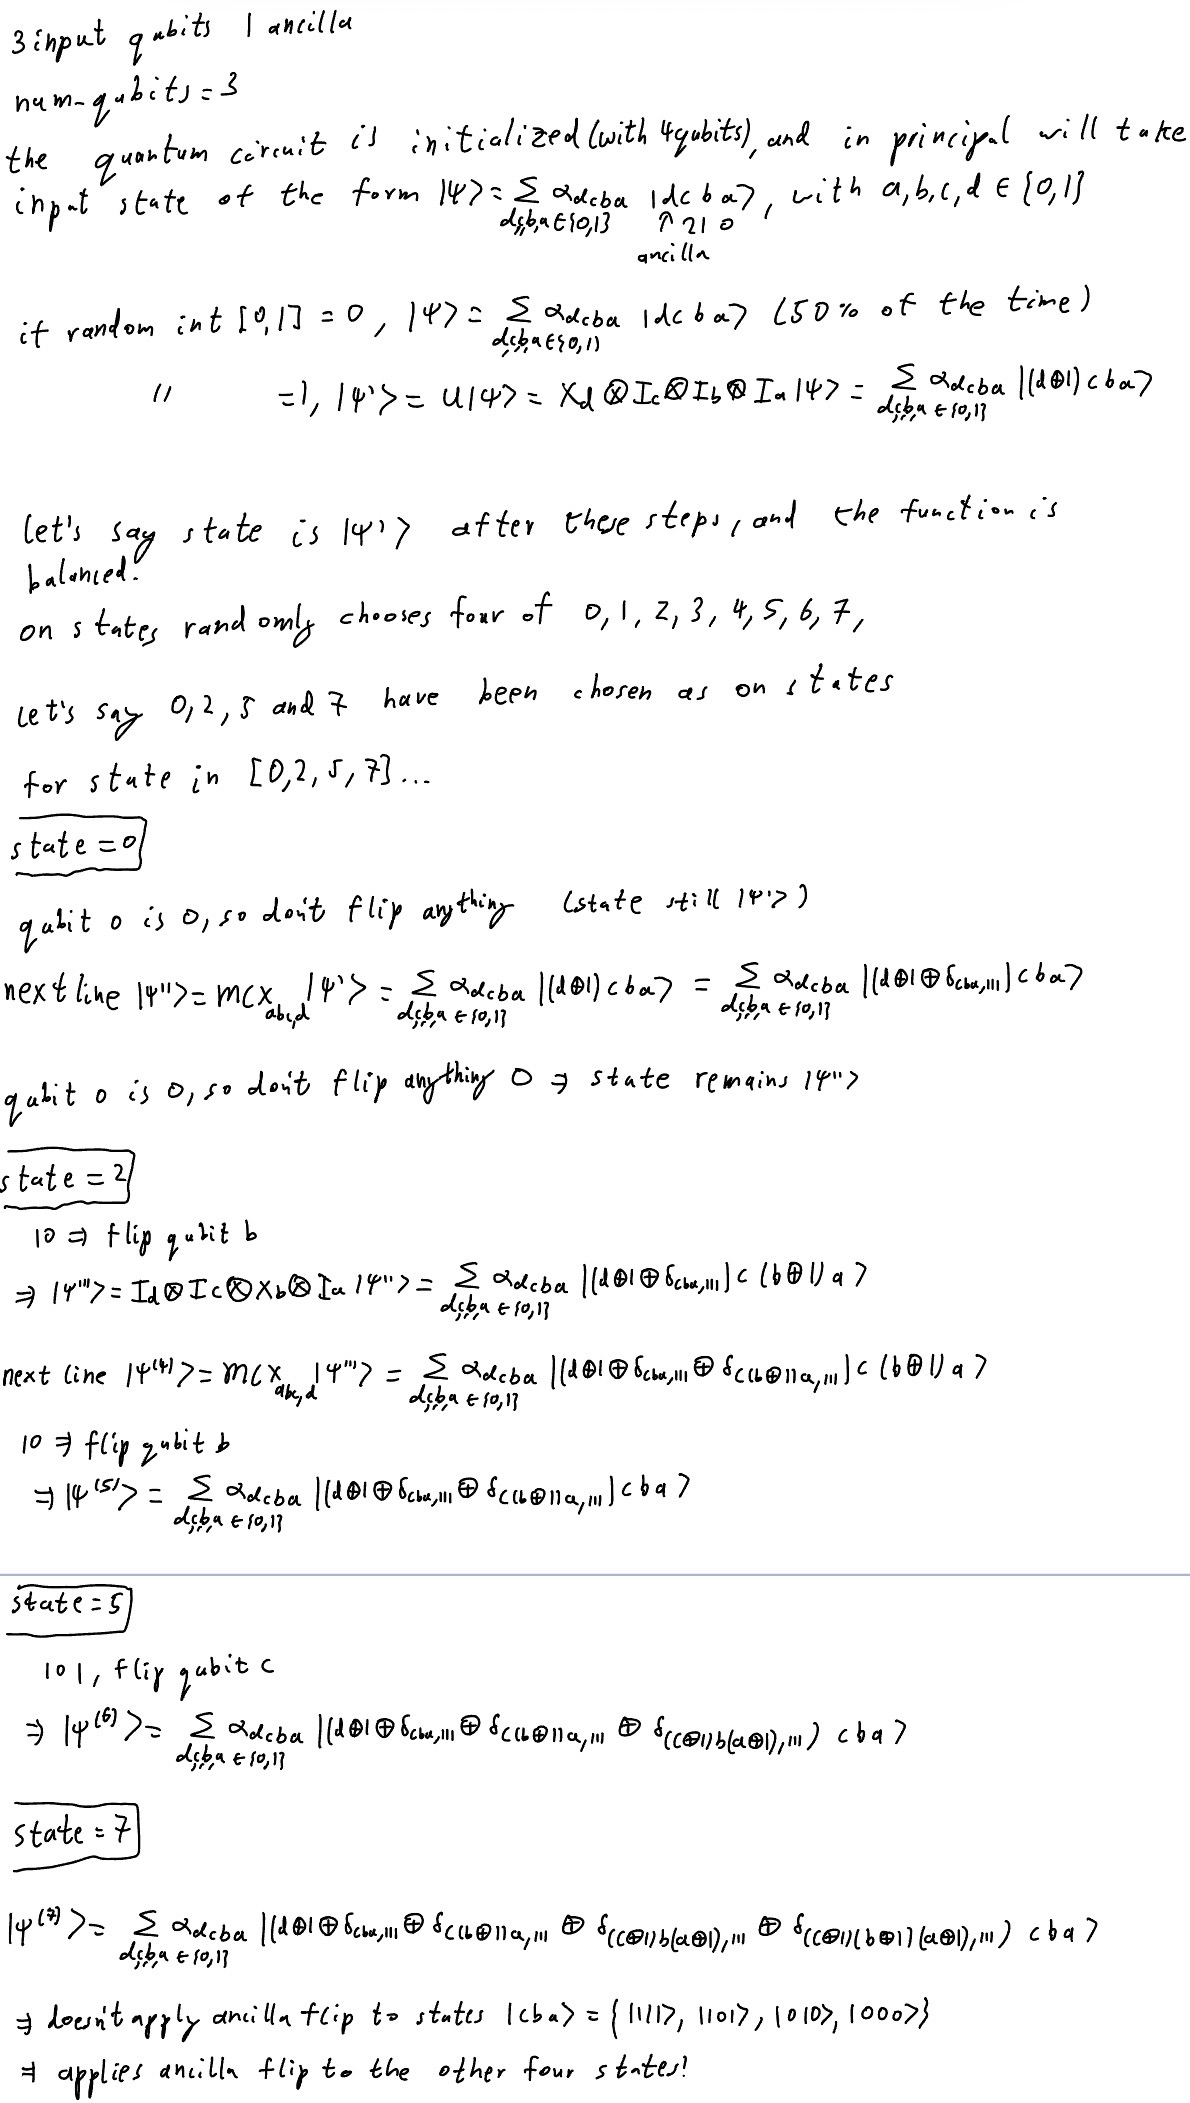

In [5]:
Image('dj_function.jpg')

Overall circuit is similar to before, but now there are 3 input qubits.

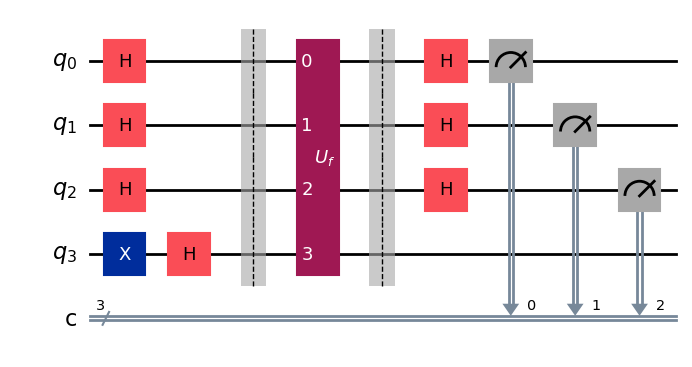

In [7]:
blackbox = oracle.to_gate()
blackbox.label = "$U_f$"
 
 
qc_dj = QuantumCircuit(n + 1, n)
qc_dj.x(n)
qc_dj.h(range(n + 1))
qc_dj.barrier()
qc_dj.compose(blackbox, inplace=True)
qc_dj.barrier()
qc_dj.h(range(n))
qc_dj.measure(range(n), range(n))
 
qc_dj.decompose().decompose()
 
 
qc_dj.draw("mpl")

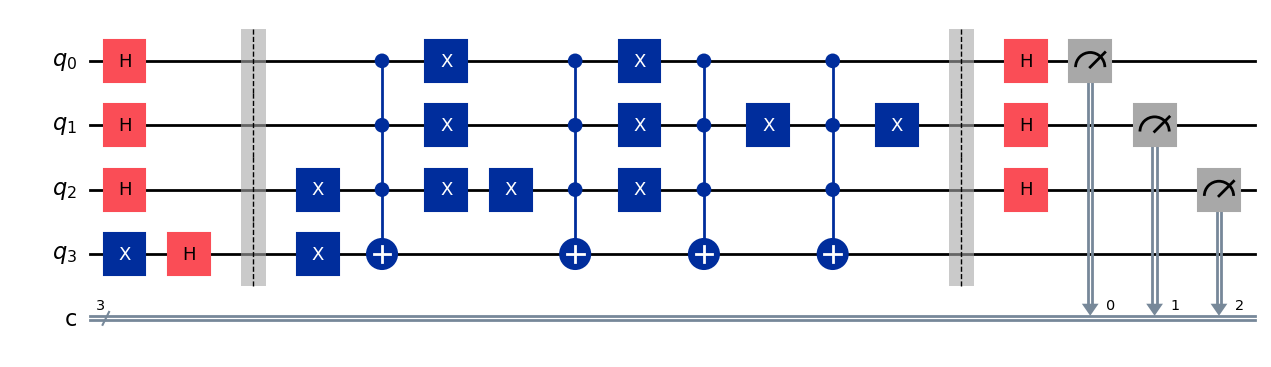

In [31]:
# Step 1: Map the problem
 
qc_dj = QuantumCircuit(n + 1, n)
qc_dj.x(n)
qc_dj.h(range(n + 1))
qc_dj.barrier()
qc_dj.compose(oracle, inplace=True)
qc_dj.barrier()
qc_dj.h(range(n))
qc_dj.measure(range(n), range(n))
 
qc_dj.decompose().decompose()
 
 
qc_dj.draw("mpl")

In [32]:
# Step 2: Transpile
 
target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
 
qc_isa = pm.run(qc_dj)

In [33]:
# Step 3: Run the job on a real quantum computer
 
job = sampler.run([qc_isa], shots=1)
# job = sampler_sim.run([qc_isa],shots=1) # uncomment this line to run on simulator instead
res = job.result()
counts = res[0].data.c.get_counts()

In [34]:
# Step 4: Visualize and analyze results
 
## Analysis
print(counts)
 
if (
    "0" * n in counts
):  # The D-J algorithm returns all zeroes if the function was constant
    print("constant")
else:
    print("balanced")  # anything other than all zeroes means the function is balanced.

{'111': 1}
balanced


With one single run, it is possible to determine whether the function is constant or balanced.

The Deutsch-Jozsa algorithm demonstrates an exponential speed up over a deterministic classical algorithm, that would require $2^{n-1}+1$ queries. A classical randomized algorithm can guess correctly with high probability after only a few queries, but never with the single query, certain result of the quantum version.

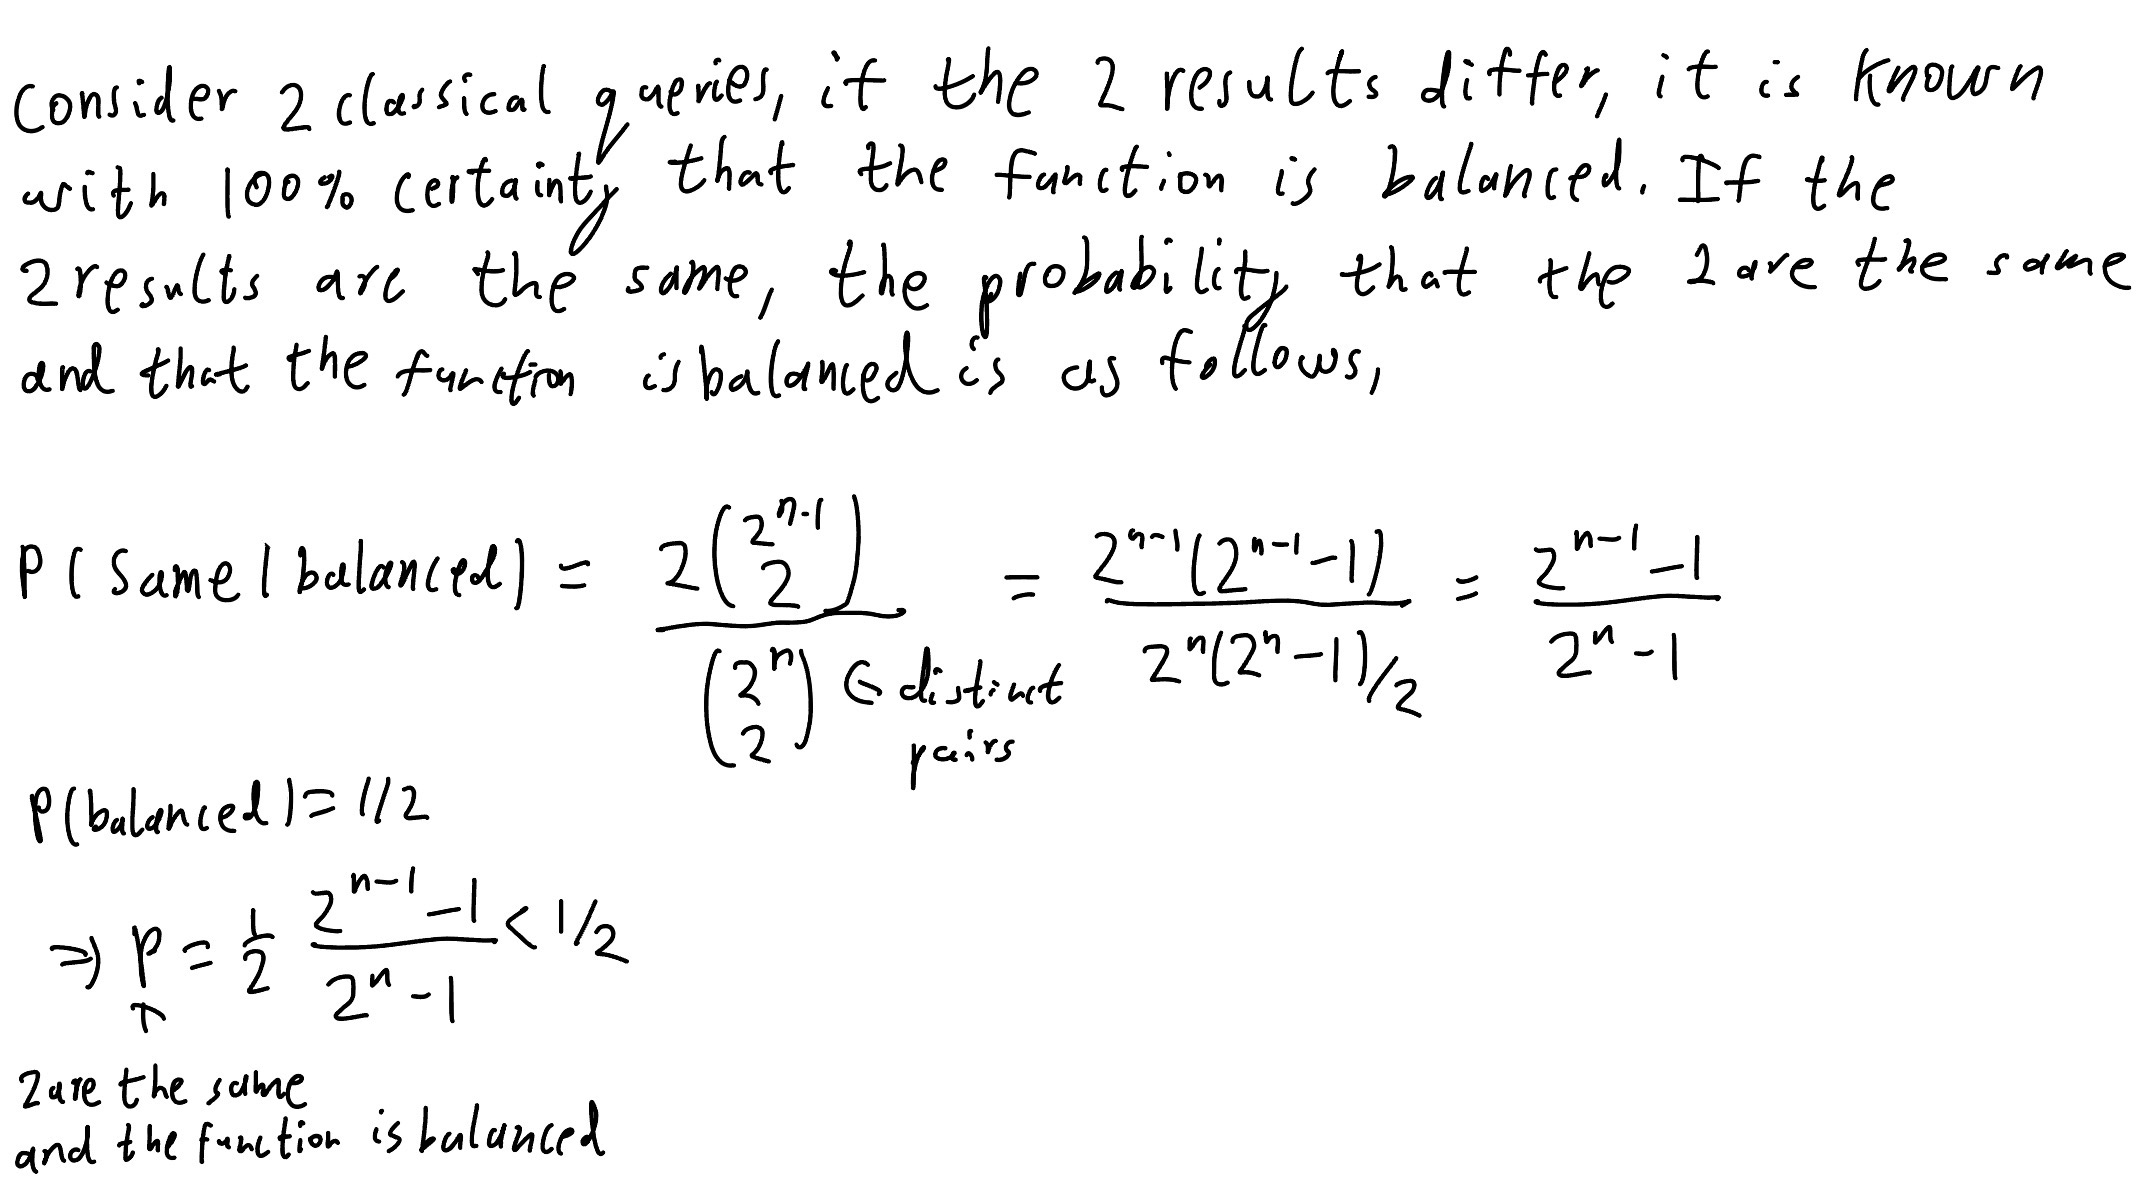

In [8]:
Image('probabilities.jpg')

## The Bernstein - Vazirani problem

Instead of just distinguishing between two classes of functions as in Deutsch–Jozsa, Bernstein and Vazirani adapted the idea to learn a hidden bit string encoded in the function.
The function is defined as $f: \{0,1\}^n \to \{0,1\},$ with $f(x) = s \cdot x \pmod{2}$, where $s$ is a n-bit string we want to find. Note that $s \cdot x \pmod{2}= s_1x_1 \oplus s_2x_2 \oplus \dots \oplus s_nx_n.$ Each query to $f(x)$ gives one bit of information about $s$, which means a classical algorithm would need $n$ separate queries. The Bernstein-Vazirani algorithm can recover all of $s$ with one query.

The steps on how this algorithm is solved are shown below.

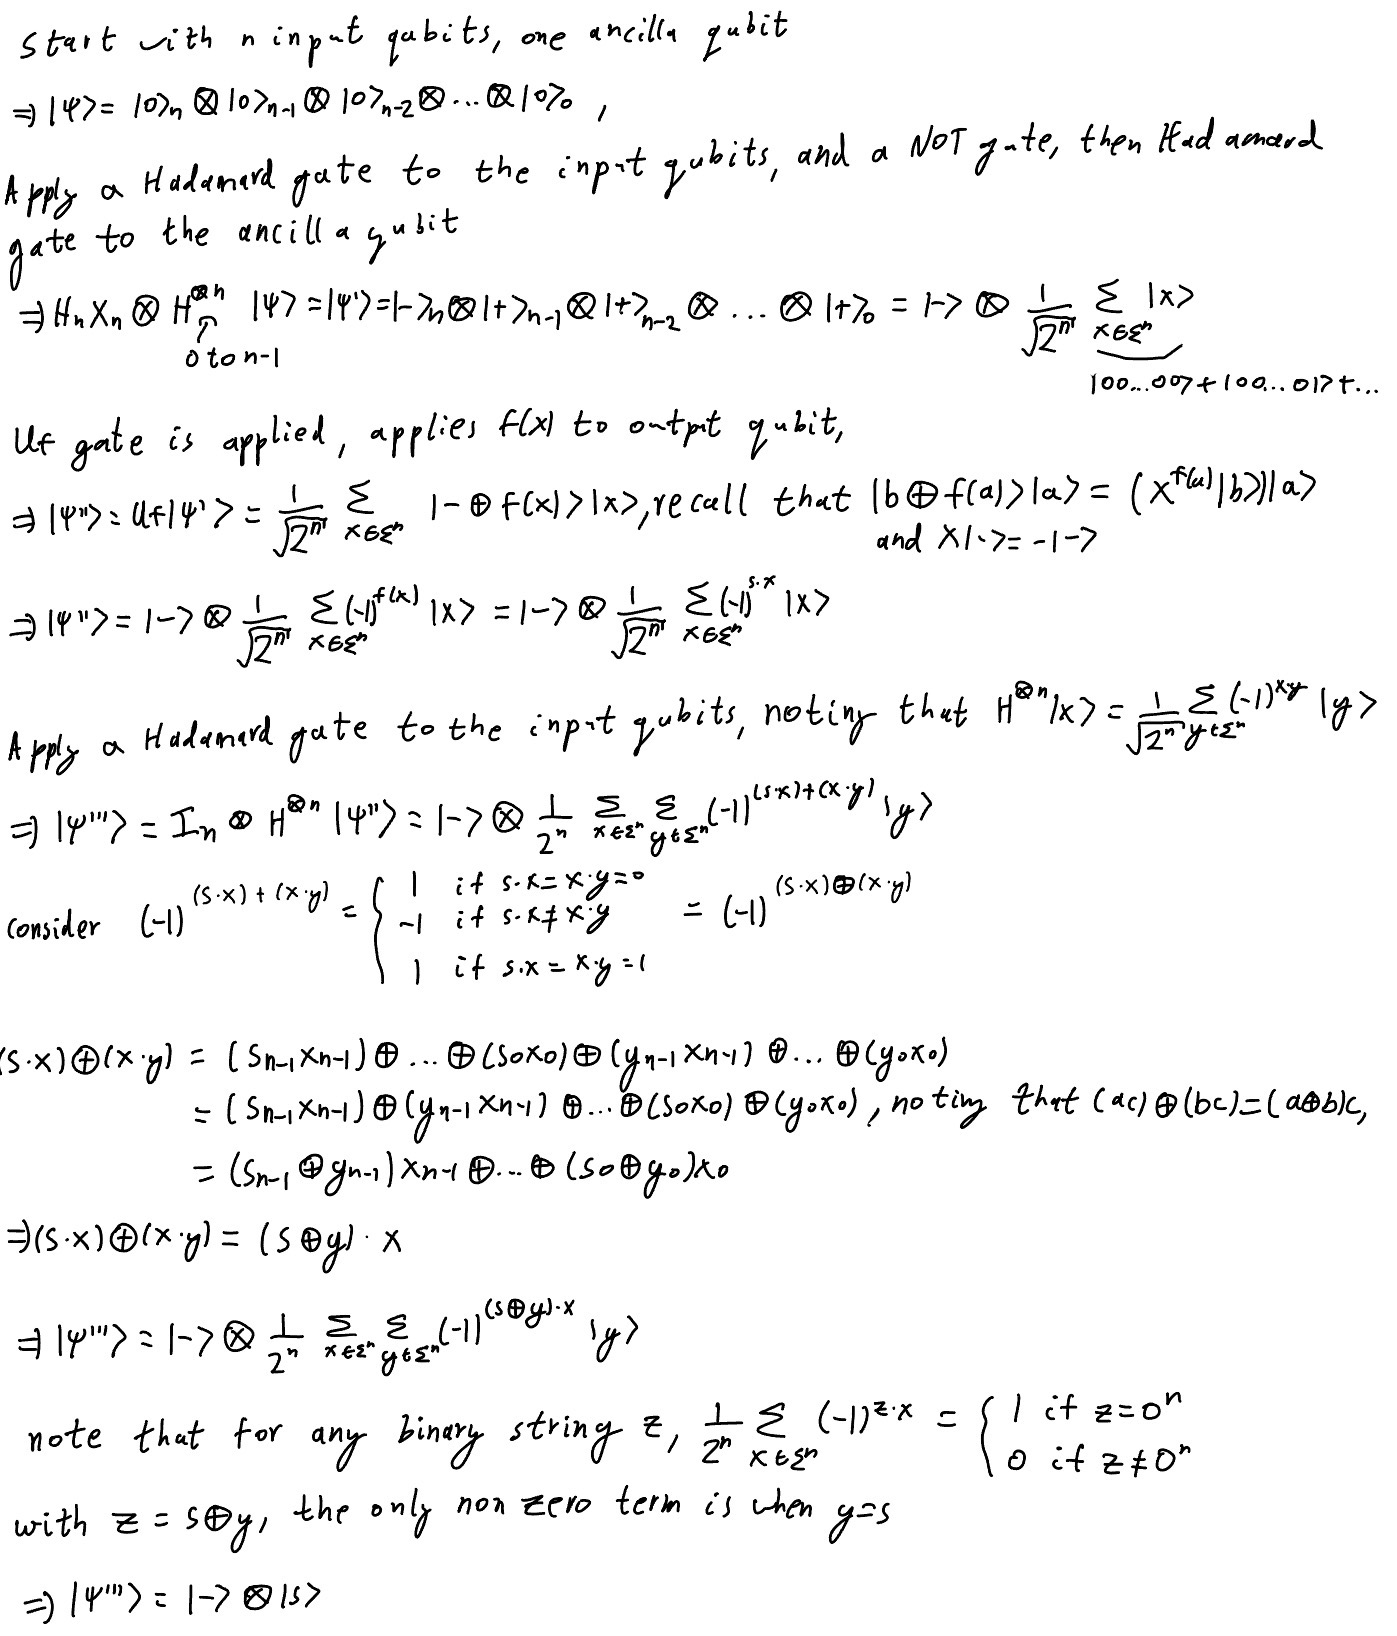

In [9]:
Image('bernstein_vazirani.jpg')

The string is encoded within the measured qubits! This is verified for $n=1$ below.

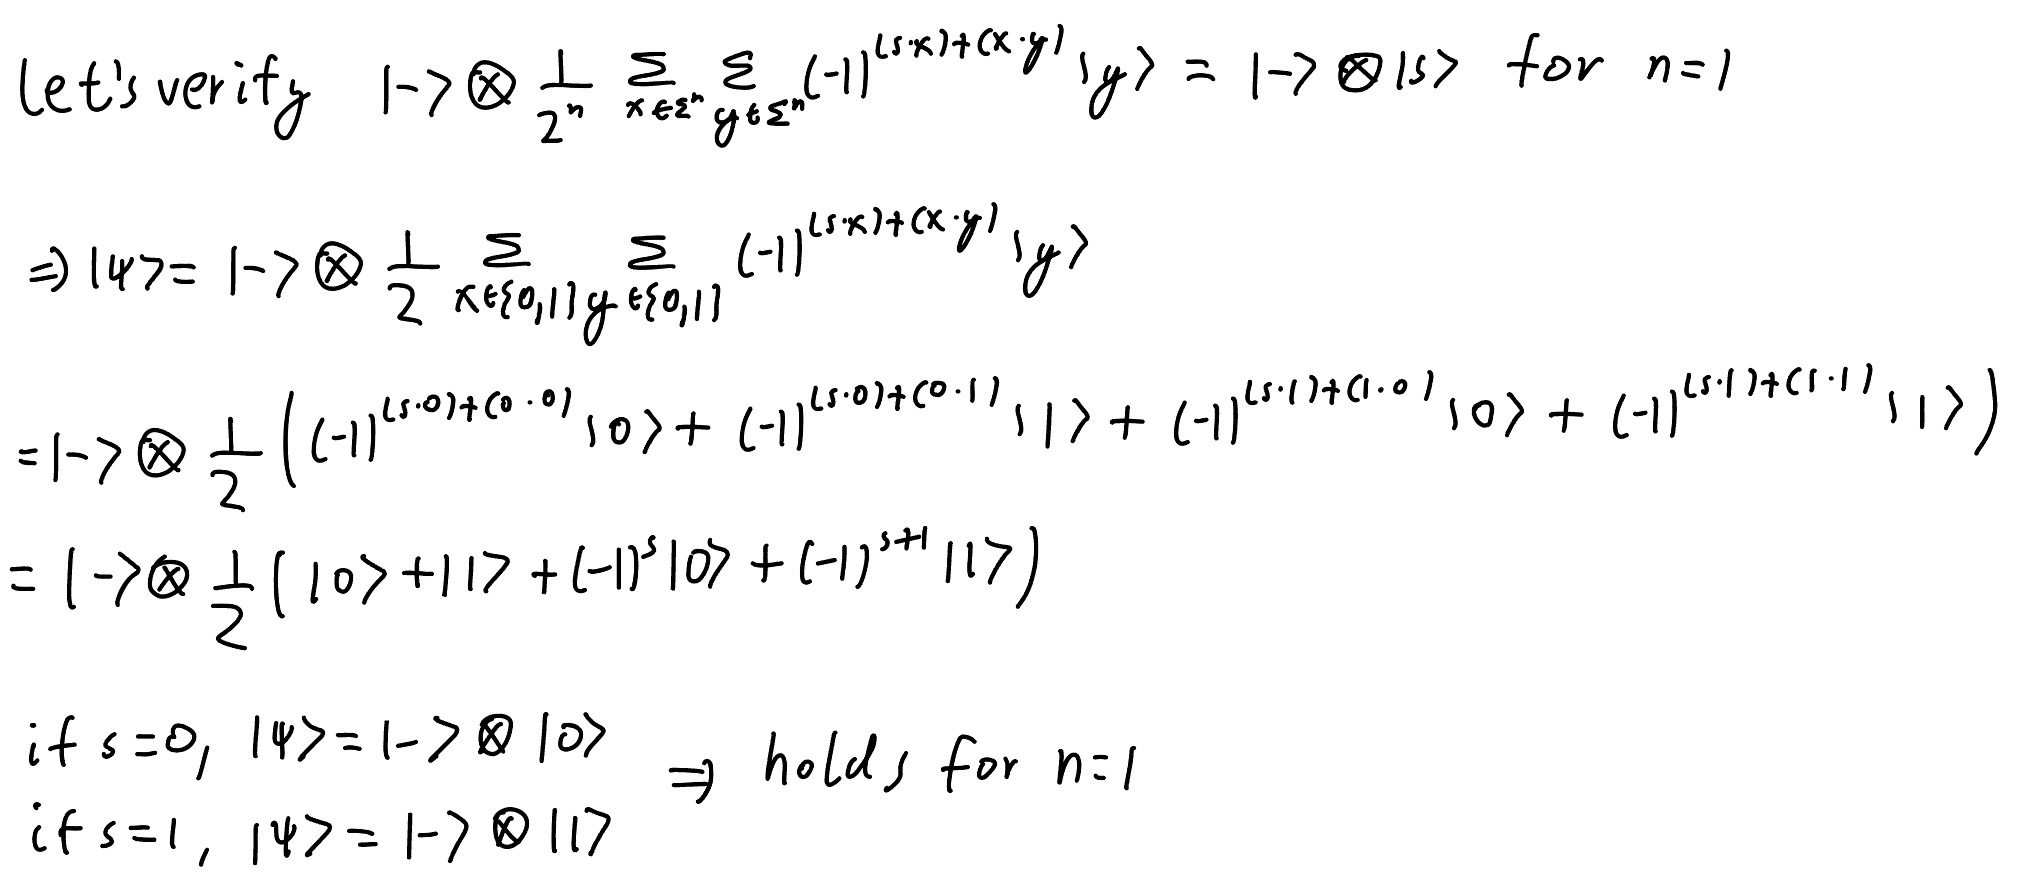

In [16]:
Image('n1.jpg')

For a Bernstein–Vazirani oracle of the form $f(x) = s \cdot x$, the function either gives $0$ for all $x$ when $s = 00\ldots0$, in which case it is constant, or gives $1$ for exactly half of all $x$ when $s \neq 00\ldots0$, in which case it is balanced. $\Rightarrow$ running the Deutsch–Jozsa algorithm on this oracle both recovers the hidden string $s$ and simultaneously tells us whether $f$ is constant or balanced.

The Bernstein-Vazirani problem is tested experimentally below.

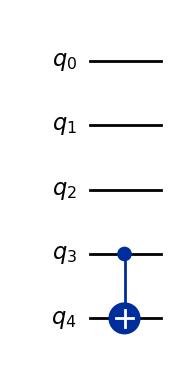

In [15]:
# Step 1: Map the problem
 
 
def bv_function(s):
    """
    Create a Bernstein-Vazirani function from a string of 1s and 0s.
    """
    qc = QuantumCircuit(len(s) + 1)
    for index, bit in enumerate(reversed(s)):
        if bit == "1":
            qc.cx(index, len(s))
    return qc
# for each 1 in s, apply CNOT with the corresponding input qubit as control and the ancilla as target
 
display(bv_function("1000").draw("mpl"))

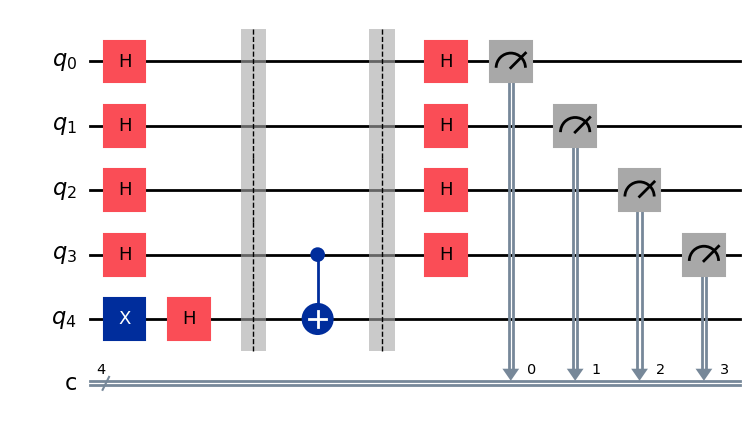

In [4]:
string = "1000"  # secret string that we'll pretend we don't know or have access to
n = len(string)
 
qc = QuantumCircuit(n + 1, n)
qc.x(n)
qc.h(range(n + 1))
qc.barrier()
# qc.compose(oracle, inplace = True)
qc.compose(bv_function(string), inplace=True)
qc.barrier()
qc.h(range(n))
qc.measure(range(n), range(n))
 
qc.draw("mpl")

In [6]:
# Step 2: Transpile
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
 
target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
 
qc_isa = pm.run(qc)

In [7]:
# Step 3: Run the job on a real quantum computer
 
job = sampler.run([qc_isa], shots=1)
# job = sampler_sim.run([qc_isa],shots=1) # uncomment this line to run on simulator instead
res = job.result()
counts = res[0].data.c.get_counts()

In [8]:
# Step 4: Visualize and analyze results
 
## Analysis
print(counts)

{'1000': 1}


The input string is returned! Since $s \neq 0000$, the corresponding Bernstein–Vazirani oracle is balanced.

## Conclusion

The lab showed how simple quantum circuits can learn global properties of a function with fewer queries than any deterministic classical method. Deutsch and Deutsch–Jozsa circuits used superposition and interference to decide if an oracle is constant or balanced in a single run, while the Bernstein–Vazirani circuit recovered an entire hidden bit string with one query. These experiments showed how phase kickback encodes useful information into measurement outcomes and why quantum query complexity can be fundamentally lower than classical query complexity.

## Questions

**True/False Questions**

1. *Deutsch's algorithm is a special case of the Deutsch-Jozsa algorithm where the input is a single qubit.*


**True**


2. *The Deutsch and Deutsch-Jozsa algorithms use quantum superposition and interference to achieve their efficiency.*


**True**, Hadamard gates are applied, and they use phase kickback.


3. *The Deutsch-Jozsa algorithm requires multiple function evaluations to determine if a function is constant or balanced.*

**False**, it needs only one query.

4. *The "Bernstein-Vazirani algorithm" is actually the same as the Deutsch-Jozsa algorithm, applied to a different problem.*

**True**, it uses the same Hadamard, Oracle, Hadamard structure as Deutsch-Jozsa, with a different oracle, of the form $f(x) = s \cdot x$.


5. *The Bernstein-Vazirani algorithm can find multiple secret strings simultaneously.*

**False**, it finds one hidden string $s$ per run.


**Short Answer**

1. *How long would it take a classical algorithm to solve the Deutsch-Jozsa problem in the worst case?*

In the worst case, it would take $2^{n-1} + 1$ function evaluations.

2. *How long would it take a classical algorithm to solve the Bernstein-Vazirani problem? What speedup does the DJ algorithm offer in this case?*

A classical algorithm would require $n$ queries to find the hidden string $s$. The Bernstein–Vazirani algorithm finds all $n$ bits in one query, which is faster by a factor of $n$.

3. *Describe the phase-kickback mechanism and how it works to solve the Deutsch-Jozsa and Bernstein-Vazirani problems.*

In both the Deutsch-Jozsa and Bernstein-Vazirani algorithms, the oracle acts as $U_f|-\rangle|x\rangle = (-1)^{f(x)}|-\rangle|x\rangle.$ Since $X|-\rangle = -|-\rangle$, the output qubit remains unchanged   while the input qubits acquire a phase $(-1)^{f(x)}$, which depends on $f(x)$. This “kicks back” information about the function into the phase of the inputs. Hadamard gates applied after cause constructive or destructive interference that show whether $f$ is constant (Deutsch–Jozsa) or encodes the hidden bit string $s$ (Bernstein–Vazirani) on measurement.

**Challenge Problem**

Verify the Deutsch-Jozsa algorithm for $n=2$

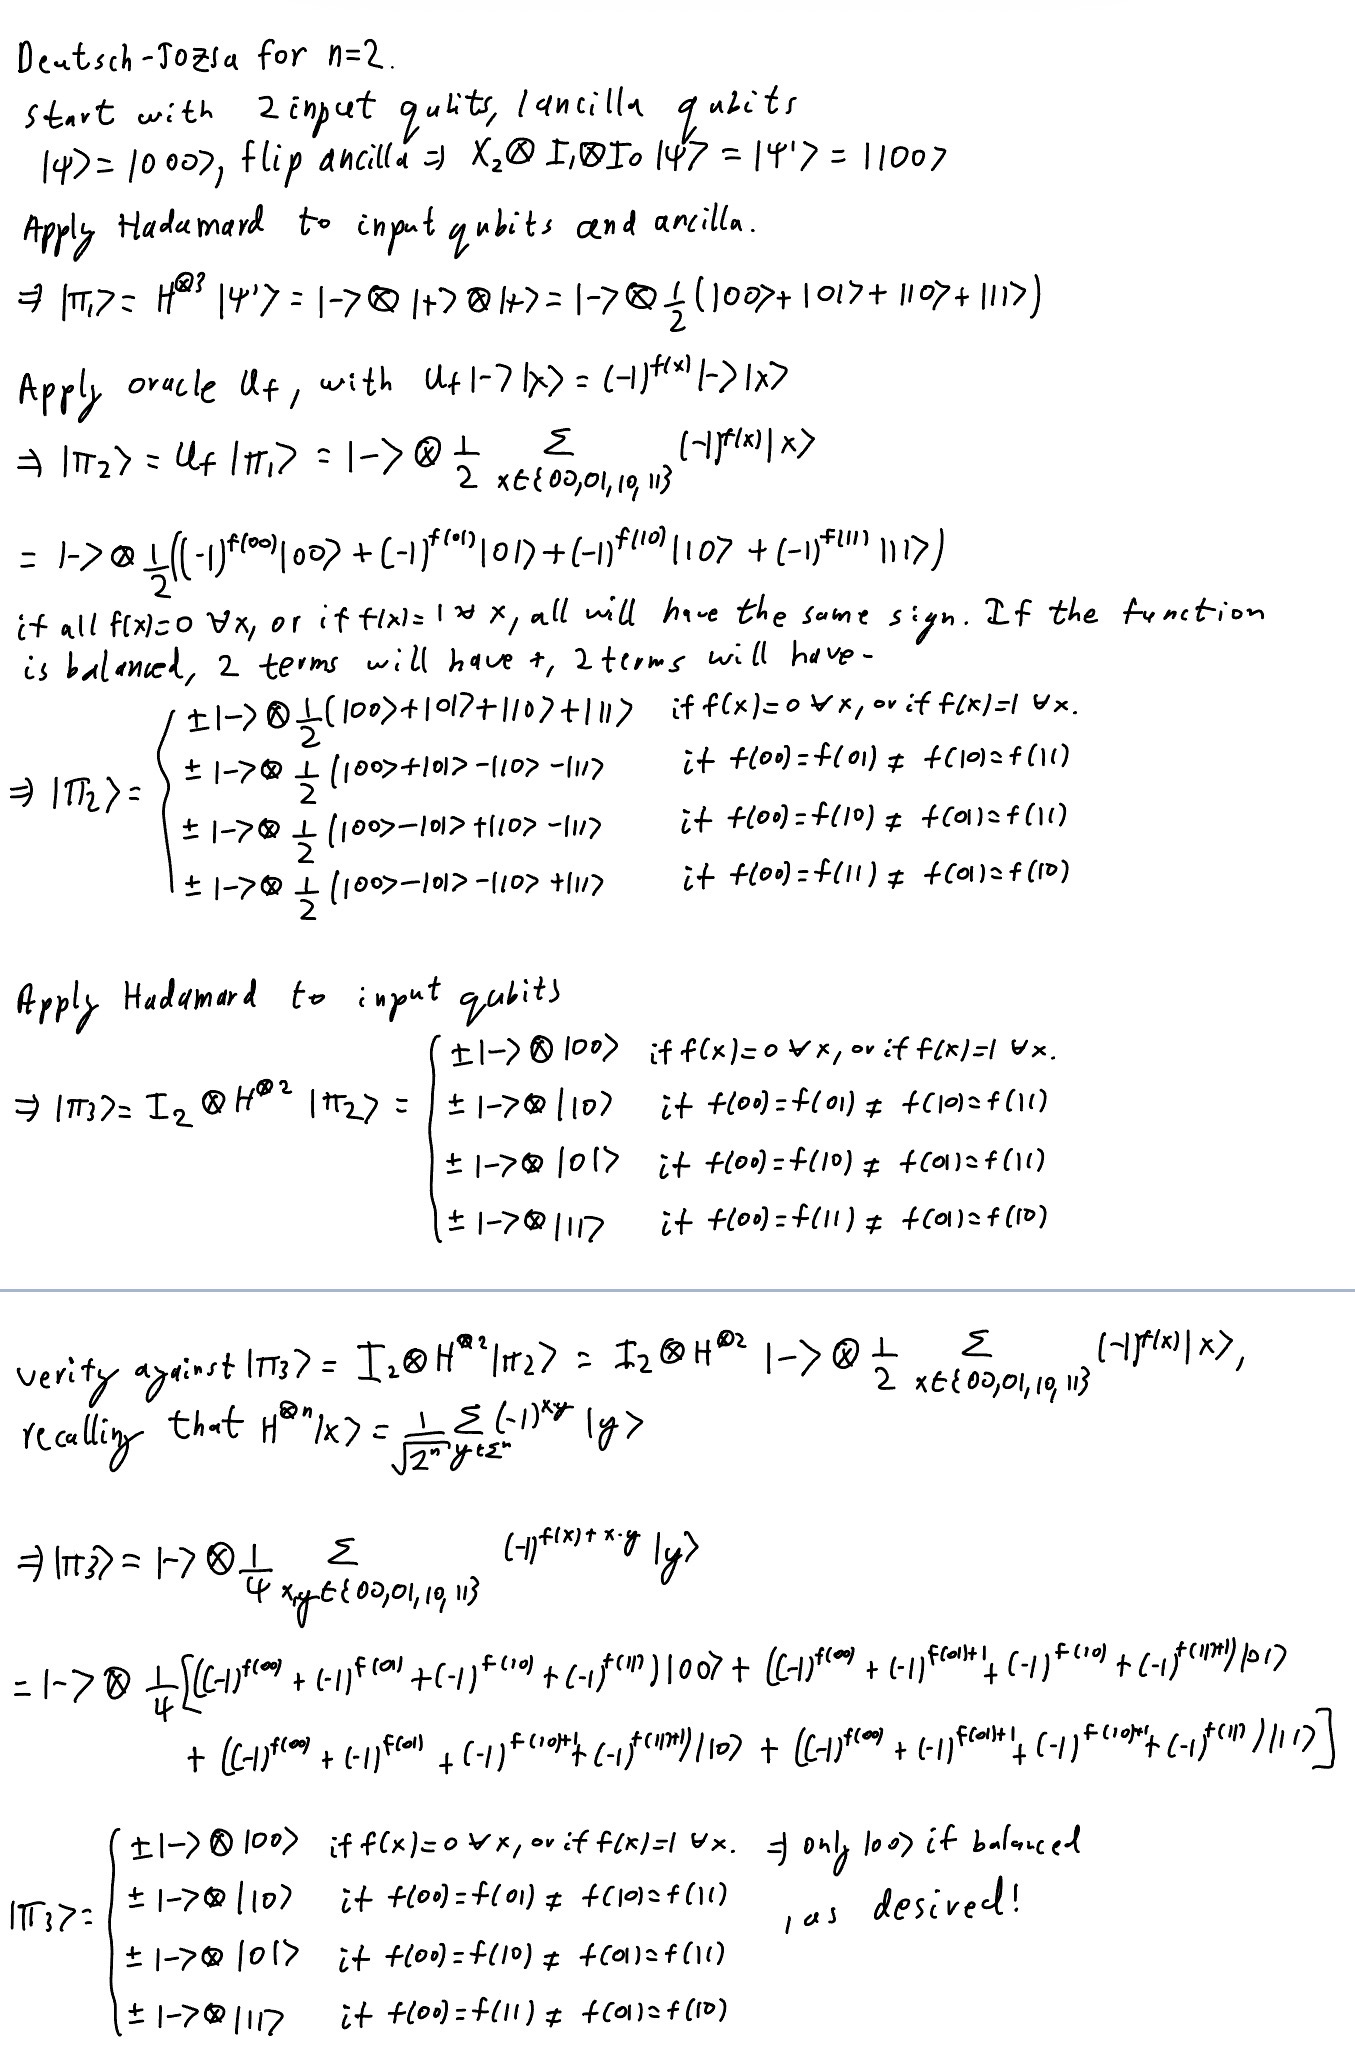

In [3]:
Image('n2.jpg')